In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

housing = pd.read_csv("../data/processed/cleaned_housing.csv")
housing['Date'] = pd.to_datetime(housing['Date'])
housing['Year'] = housing['Date'].dt.year
housing['Month'] = housing['Date'].dt.month
housing.head()

,Date,RegionName,AveragePrice,SalesVolume,DetachedPrice,SemiDetachedPrice,TerracedPrice,FlatPrice,CashPrice,MortgagePrice,Year,Month
0,1968-01-04,West Midlands Region,3188,84.0,143462.0,75833.0,58017.0,48090.0,94689.0,105153.0,1968,1
1,1968-01-04,Yorkshire and The Humber,2553,84.0,143462.0,75833.0,58017.0,48090.0,94689.0,105153.0,1968,1
2,1968-01-04,London,4730,84.0,143462.0,75833.0,58017.0,48090.0,94689.0,105153.0,1968,1
3,1968-01-04,Northern Ireland,3465,84.0,143462.0,75833.0,58017.0,48090.0,94689.0,105153.0,1968,1
4,1968-01-04,Scotland,2738,84.0,143462.0,75833.0,58017.0,48090.0,94689.0,105153.0,1968,1


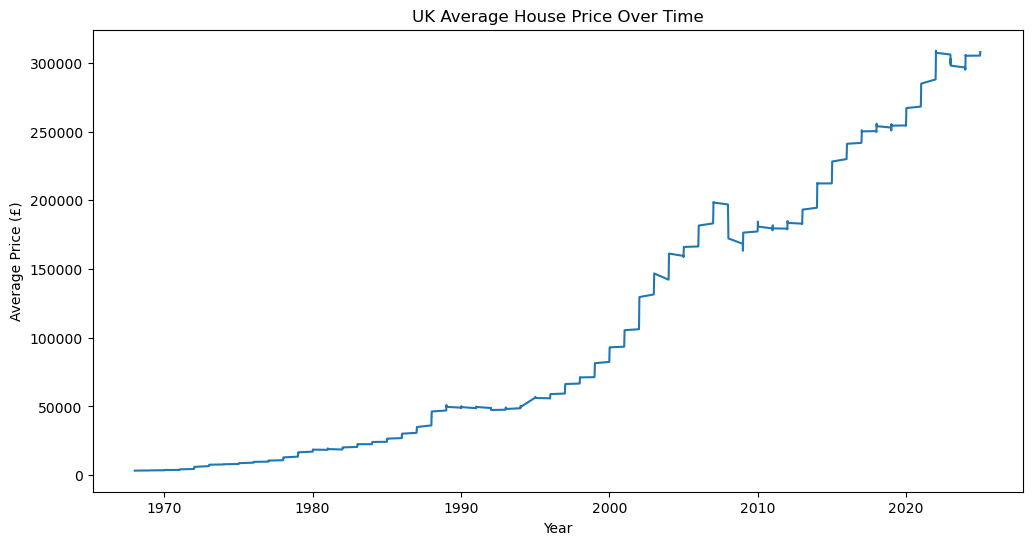

In [5]:
uk_trend = housing.groupby('Date')['AveragePrice'].mean()

plt.figure(figsize=(12,6))
plt.plot(uk_trend)
plt.title("UK Average House Price Over Time")
plt.xlabel("Year")
plt.ylabel("Average Price (£)")
plt.show()

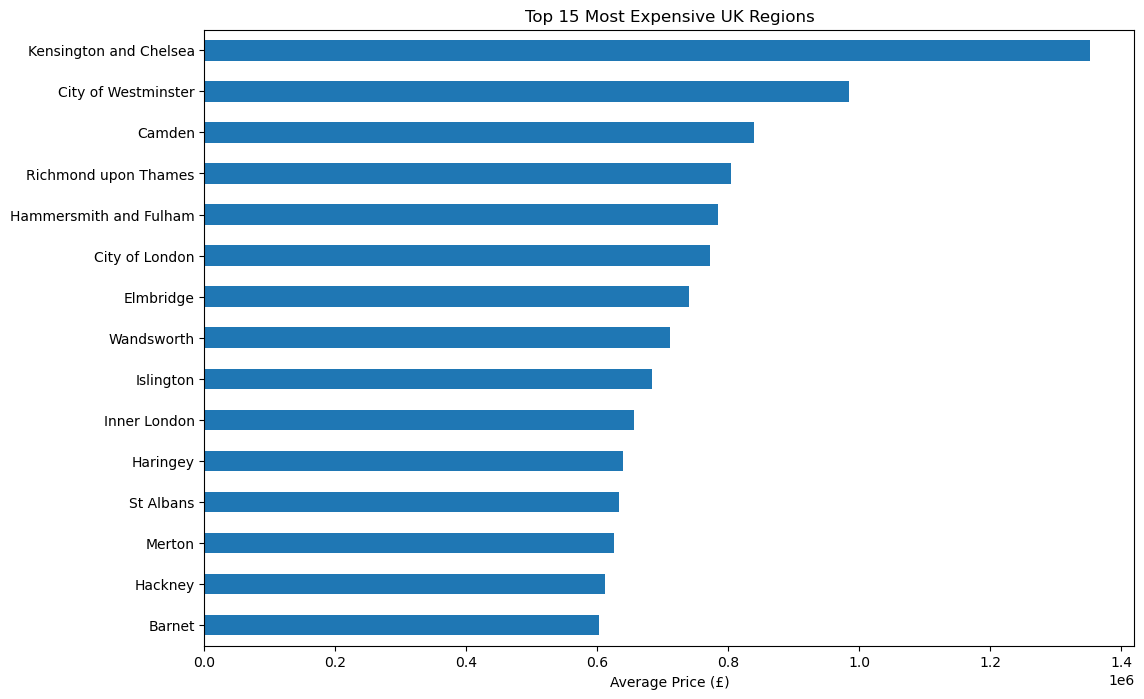

In [7]:
latest_year = housing[housing['Year'] == housing['Year'].max()]

region_prices = (
    latest_year.groupby('RegionName')['AveragePrice']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,8))
region_prices.sort_values().plot(kind='barh')
plt.title("Top 15 Most Expensive UK Regions")
plt.xlabel("Average Price (£)")
plt.ylabel("")
plt.show()

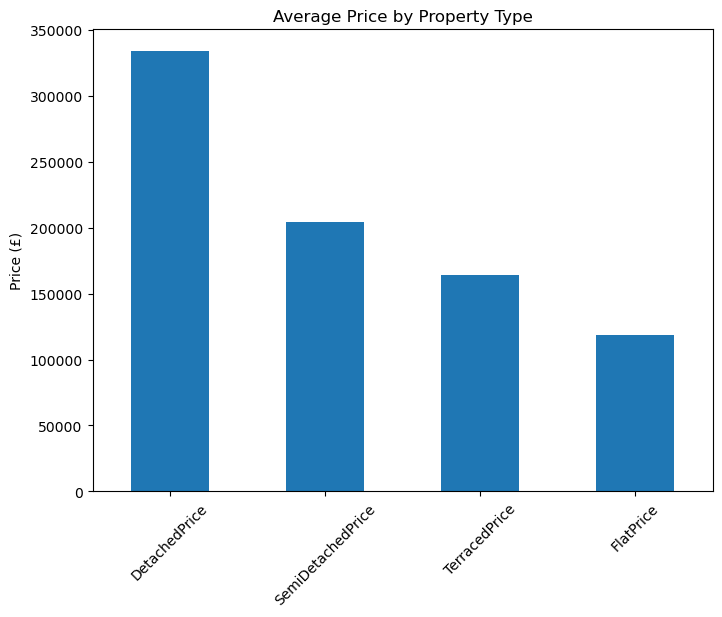

In [8]:
property_cols = [
    'DetachedPrice','SemiDetachedPrice',
    'TerracedPrice','FlatPrice'
]

avg_prices = housing[property_cols].mean()

plt.figure(figsize=(8,6))
avg_prices.plot(kind='bar')
plt.title("Average Price by Property Type")
plt.ylabel("Price (£)")
plt.xticks(rotation=45)
plt.show()

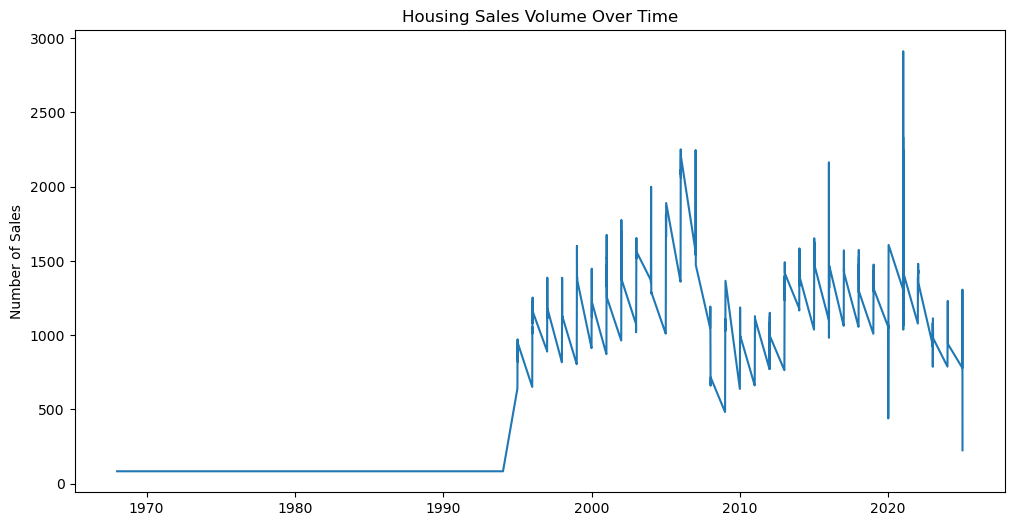

In [9]:
sales_trend = housing.groupby('Date')['SalesVolume'].mean()

plt.figure(figsize=(12,6))
plt.plot(sales_trend)
plt.title("Housing Sales Volume Over Time")
plt.ylabel("Number of Sales")
plt.show()

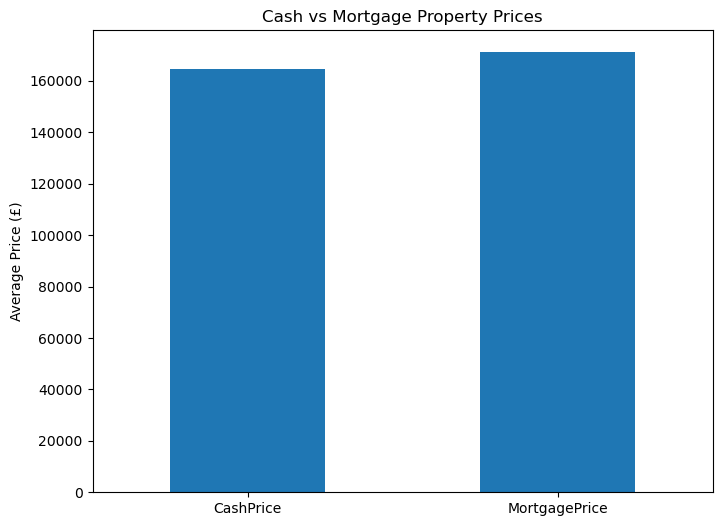

In [10]:
cash_vs_mortgage = housing[['CashPrice','MortgagePrice']].mean()

plt.figure(figsize=(8,6))
cash_vs_mortgage.plot(kind='bar')
plt.title("Cash vs Mortgage Property Prices")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=0)
plt.show()

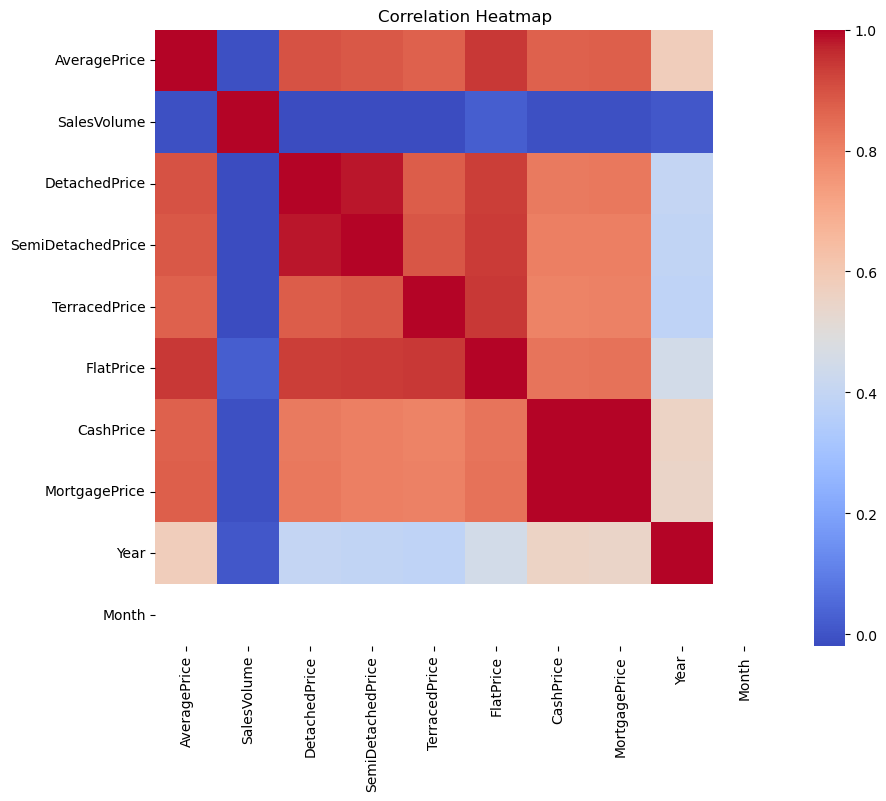

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(housing.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Key Business Insights

#### 1.Strong Long-Term Growth in UK Housing Prices

The time-series analysis shows a consistent upward trend in UK house prices over the years, with a noticeable acceleration after 2020. This likely reflects post-pandemic housing demand, low interest rates, and remote-work driven relocation trends.

Business implication:
Housing affordability is decreasing, and demand remains strong despite economic uncertainty.

#### 2.Significant Regional Price Inequality

The regional comparison shows large differences between UK regions. London and South East regions dominate the top price range, while northern regions remain significantly more affordable.

Business implication:
Location is the strongest driver of property value. Real estate investment strategies should prioritise high-growth regions.

#### 3.Property Type Strongly Influences Price

Detached properties have the highest average price, followed by semi-detached, terraced houses, and flats.

Business implication:
Property type is a key feature for price prediction models and should be prioritised in real-estate valuation systems.

#### 4.Market Activity Fluctuates Over Time

Sales volume trends show dips during economic uncertainty periods and spikes during favourable lending conditions.

Business implication:
Housing demand is sensitive to macroeconomic conditions such as interest rates and economic confidence.

#### 5.Mortgage Buyers Pay Higher Prices than Cash Buyers

Mortgage-financed purchases show higher average prices compared to cash purchases.

Business implication:
Access to financing enables buyers to purchase higher-value properties, indicating credit availability strongly affects market behaviour.